In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.utils as vutils
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

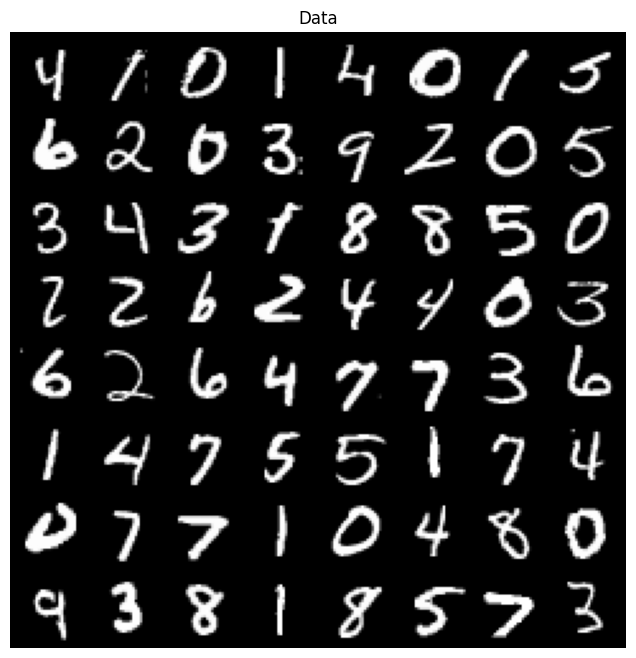

In [4]:
images, _ = next(iter(train_loader))

images = images * 0.5 + 0.5

grid = torchvision.utils.make_grid(images[:64])

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Data")
plt.show()

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [6]:
class Generator(nn.Module):
        def __init__(self):
            super(Generator, self).__init__()

            self.model = nn.Sequential(
                nn.Linear(100, 256),
                nn.LeakyReLU(0.2),
                
                nn.Linear(256, 512),
                nn.LeakyReLU(0.2),
                
                nn.Linear(512, 1024),
                nn.LeakyReLU(0.2),
                
                nn.Linear(1024, 28*28)
            )   

        def forward(self, x):
              return self.model(x)

In [7]:
g = Generator().to(device)
d = Discriminator().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_g = optim.Adam(g.parameters(), lr=0.001)
optimizer_d = optim.Adam(d.parameters(), lr=0.001)

In [8]:
num_epochs = 20

generator_losses = []
discriminator_losses = []

In [9]:
def show_generated_images(generator, epoch, device, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, 100).to(device)

    with torch.no_grad():
        fake_images = generator(noise).view(num_images, 1, 28, 28) 
        fake_images = (fake_images + 1) / 2  

    grid_img = vutils.make_grid(fake_images.cpu(), nrow=4, padding=2, normalize=True)

    plt.figure(figsize=(6,6))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title(f"Generated Images at Epoch {epoch+1}")
    plt.axis('off')
    plt.show()

    generator.train()

Epoch [1/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [2/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [3/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [4/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [5/20]  Loss_D: 1.6265  Loss_G: 0.3133


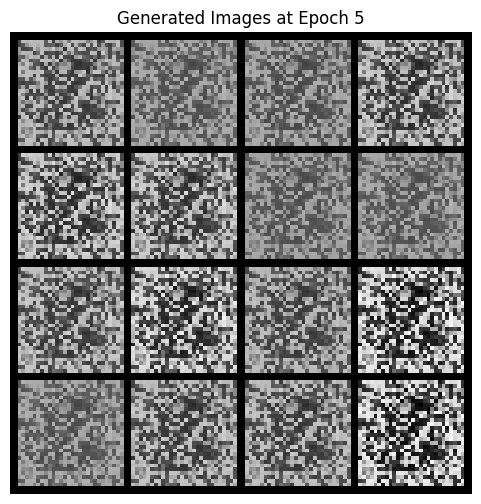

Epoch [6/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [7/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [8/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [9/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [10/20]  Loss_D: 1.6265  Loss_G: 0.3133


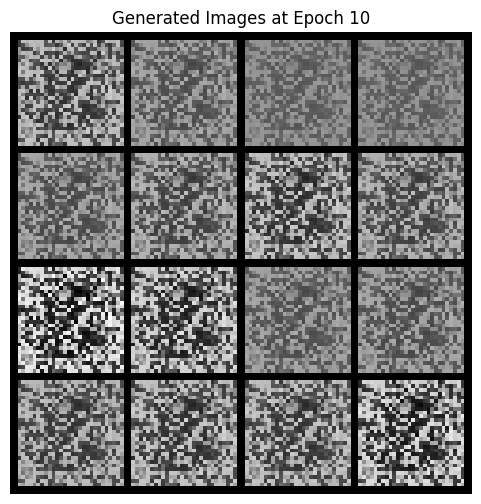

Epoch [11/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [12/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [13/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [14/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [15/20]  Loss_D: 1.6265  Loss_G: 0.3133


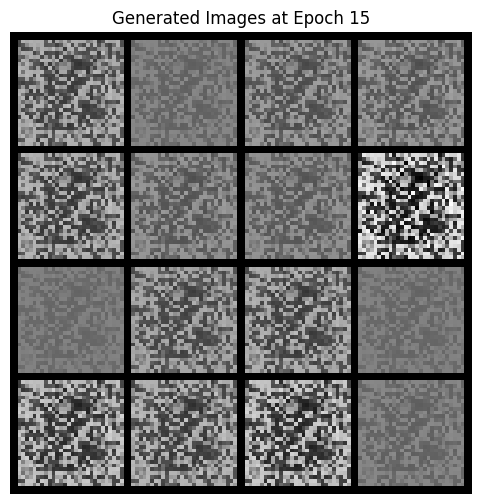

Epoch [16/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [17/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [18/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [19/20]  Loss_D: 1.6265  Loss_G: 0.3133
Epoch [20/20]  Loss_D: 1.6265  Loss_G: 0.3133


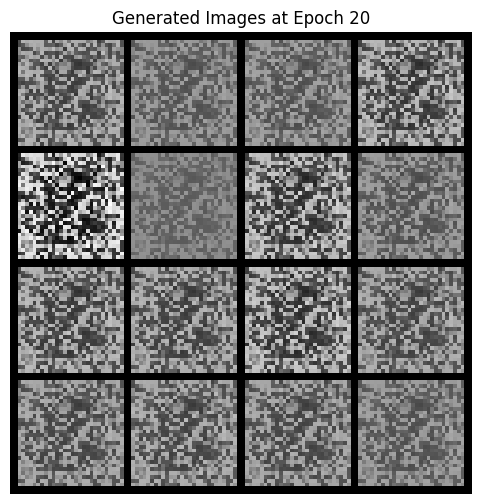

In [10]:
for epoch in range(num_epochs):
    g.train()
    d.train()
    for batch_idx, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)

        real_images = real_images.view(batch_size, -1).to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        noise = torch.randn(batch_size, 100).to(device)
        
        fake_images = g(noise).detach()

        d_real = d(real_images)
        d_fake = d(fake_images)

        loss_real = criterion(d_real, real_labels)
        loss_fake = criterion(d_fake, fake_labels)
        loss_d = loss_real + loss_fake

        optimizer_d.zero_grad()
        loss_d.backward()
        optimizer_d.step()

        noise = torch.randn(batch_size, 100).to(device)

        fake_images = g(noise)

        d_output = d(fake_images)

        loss_g = criterion(d_output, real_labels)

        optimizer_g.zero_grad()
        loss_g.backward()
        optimizer_g.step()

    generator_losses.append(loss_g.item())
    discriminator_losses.append(loss_d.item())

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss_D: {loss_d.item():.4f}  Loss_G: {loss_g.item():.4f}")

    if (epoch + 1) % 5 == 0:
        show_generated_images(g, epoch, device)



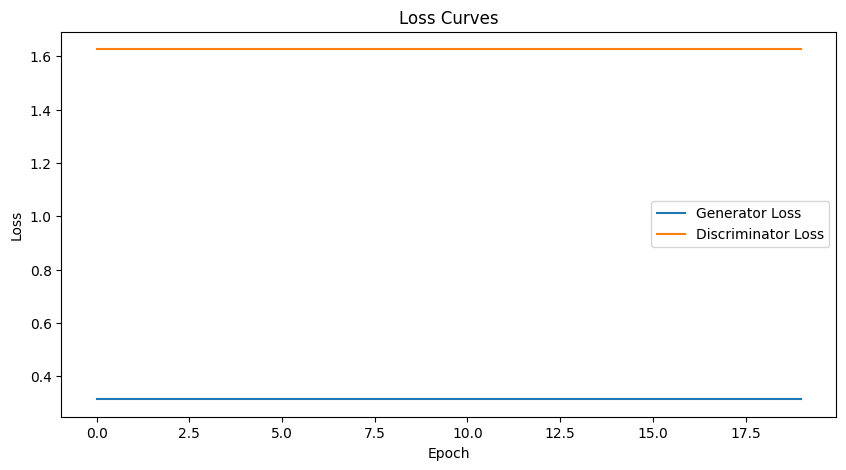

In [11]:
plt.figure(figsize=(10,5))
plt.plot(generator_losses, label='Generator Loss')
plt.plot(discriminator_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

In [12]:
g = Generator()
g.to(device)
g.eval()

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
  )
)

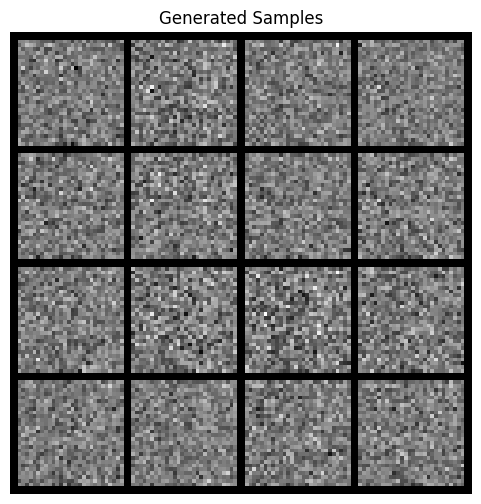

In [13]:
num_samples = 16
noise = torch.randn(num_samples, 100).to(device)

with torch.no_grad():
    fake_images = g(noise).view(num_samples, 1, 28, 28)
    fake_images = (fake_images + 1) / 2 

grid_img = vutils.make_grid(fake_images.cpu(), nrow=4, padding=2, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(grid_img.permute(1, 2, 0))
plt.title("Generated Samples")
plt.axis('off')
plt.show()